In [ ]:
## installing packages
!pip install xclim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.6/382.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.0 MB/s eta 0:00:00


In [ ]:
## functions and packages
import operator
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray
from xclim.indices import run_length

import xclim

def normalize(da):
    return (da - da.min()) / (da.max() - da.min())

def calculate_meteorological_summaries(xrdata, summaries_config):

    summaries_xr = {}

    mean_summary_vars = ['temp_avg', 'hr_avg', 'hr06_avg', 'hr09_avg', 'hr12_avg', 'hr15_avg', 'hr18_avg', 'dewtemp_avg', 'vpd_avg', 'etr_avg', 'srad_avg']
    for k, v in summaries_config.items():
      var_name = v
      if '_avg' in k:
        summaries_xr[k] = getattr(xrdata[var_name], "mean")(dim="time", keep_attrs=True)
      if '_accum' in k:
        var_name = v
        summaries_xr[k] = xrdata[var_name].sum(dim="time", keep_attrs=True)

    for key, value in summaries_xr.items():
        if isinstance(value, xarray.Dataset):
            nombre_var_interna = list(value.data_vars)[0]
            summaries_xr[key] = value[nombre_var_interna]

    summaries_ds = xarray.Dataset(summaries_xr)

    if "dtd_monthly" in summaries_config:
        var_tmax, var_tmin = summaries_config["dtd_monthly"]

        collection_date = pd.to_datetime(xrdata.time.values.max())

        range_days = pd.Index(xrdata.time.values) - pd.to_datetime(collection_date)
        partial_monthlydates = np.arange(-180, 1, 30)

        dtd = (xrdata[var_tmax] + xrdata[var_tmin])
        dtd = dtd.assign_coords(monthly=("time", range_days.days))

        dtd_monthly = dtd.groupby_bins('monthly', bins=partial_monthlydates).mean()
        dtd_monthly.coords['monthly_bins'] = [f"dtd_m{i+1}" for i in range(len(dtd_monthly.monthly_bins))]
        dtd_vars_ds = dtd_monthly.to_dataset(dim='monthly_bins')
        dtd_vars_ds = dtd_monthly.to_dataset(dim='monthly_bins')

        summaries_ds = xarray.merge([summaries_ds, dtd_vars_ds])

    return summaries_ds

def get_avg_spell_length(precip_1d, threshold=1.0, window=5, cond_op='>=', window_op='>='):

    ops = {
      '>': operator.gt,
      '<': operator.lt,
      '>=': operator.ge,
      '<=': operator.le,
      '==': operator.eq
    }

    mask = ops[cond_op](precip_1d,threshold)
    padded = np.pad(mask, (1, 1), mode='constant', constant_values=False)

    diffs = np.diff(padded.astype(int))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]

    lengths = ends - starts

    valid_lengths = lengths[ops[window_op](lengths,window)]

    if len(valid_lengths) > 0:
        return np.mean(valid_lengths)
    else:
        return np.nan

def calculate_indices(xrdata , climate_indices):

  climate_indices_xr = {}

  if "vpd_lt_15" in climate_indices:
    var_name, thresh = climate_indices["vpd_lt_15"]
    climate_indices_xr["vpd_lt_15"] = (threshold_days(xrdata[var_name], thresh, meteorological_var= 'vpd', op = '<=')/len(ds.time))*100

  if "n_vpd_spells" in climate_indices:
    var_name, thresh, window = climate_indices["n_vpd_spells"]
    is_humid = xrdata[var_name] <= thresh
    climate_indices_xr["n_vpd_spells"] = run_length.windowed_run_events(is_humid, window=window, dim="time")

  if "n_wet_spells" in climate_indices:
    var_name, thresh, window = climate_indices["n_wet_spells"]
    is_wet = xrdata[var_name] >= thresh
    climate_indices_xr["n_wet_spells"] = run_length.windowed_run_events(is_wet,window=window, dim="time")

  if "n_dry_spells" in climate_indices:
    var_name, thresh, window = climate_indices["n_dry_spells"]
    is_wet = xrdata[var_name] < thresh
    climate_indices_xr["n_dry_spells"] = run_length.windowed_run_events(is_wet,window=window, dim="time")

  if "avg_wet_spell_duration" in climate_indices:
    var_name, thresh, window = climate_indices["avg_wet_spell_duration"]
    climate_indices_xr["avg_wet_spell_duration"] = xarray.apply_ufunc(
        get_avg_spell_length,
        xrdata[var_name],
        kwargs={'threshold': thresh, 'window': window, 'cond_op': '>=', 'window_op': '>='},
        input_core_dims=[['time']],
        output_core_dims=[[]],
        vectorize=True,
        dask='allowed',
        output_dtypes=[float]
    )

  if "avg_dry_spell_duration" in climate_indices:
    var_name, thresh, window = climate_indices["avg_dry_spell_duration"]
    climate_indices_xr["avg_dry_spell_duration"] =  xarray.apply_ufunc(
        get_avg_spell_length,
        xrdata[var_name],
        kwargs={'threshold': thresh, 'window': window, 'cond_op': '<', 'window_op': '>='},
        input_core_dims=[['time']],
        output_core_dims=[[]],
        vectorize=True,
        dask='allowed',
        output_dtypes=[float]
    )

  if "rh_85_90_days" in climate_indices:
    var_name, thresholds, op_symbols = climate_indices["rh_85_90_days"]
    if isinstance(var_name, list):
      for var in var_name:
        newvarname = f'{var}_85_90_days'
        climate_indices_xr[newvarname] = multiple_threshold_days(xrdata[var], values = thresholds, op_symbols=op_symbols, meteorological_var= 'hr')

  if "tmean_25_30_days" in climate_indices:
    var_name, thresholds, op_symbols = climate_indices["tmean_25_30_days"]
    climate_indices_xr["tmean_25_30_days"] = multiple_threshold_days(xrdata[var_name], values = thresholds, op_symbols=op_symbols, meteorological_var= 'hr')

  if "max_temp_days" in climate_indices:
    var_name, thresh = climate_indices["max_temp_days"]
    maxdaytemp = threshold_days(xrdata[var_name], thresh, meteorological_var= 'temp', op = '>=')
    climate_indices_xr["max_temp_days"] = maxdaytemp

  if "max_hr_days" in climate_indices:
    var_name, thresh = climate_indices["max_hr_days"]
    maxdayhr = threshold_days(xrdata[var_name], thresh, meteorological_var='hr', op='>=')
    climate_indices_xr["max_hr_days"] = maxdayhr

  if "precip_max_15d" in climate_indices:

    var_name = climate_indices["precip_max_15d"]
    pid_15 = xrdata[var_name].rolling(time=15).sum().max(dim='time')
    climate_indices_xr["precip_max_15d"] = pid_15

  if "consecutive_dry_days" in climate_indices:
    var_name, thresh = climate_indices["consecutive_dry_days"]
    consec_dry_days = consecutive_days(xrdata[var_name], value=thresh, meteorological_var='prec', op='<')
    climate_indices_xr["consecutive_dry_days"] = consec_dry_days

  if "growing_degree_days" in climate_indices:
    var_name, tbase = climate_indices["growing_degree_days"]
    gdd = (xrdata[var_name] - tbase).sum(dim='time', keep_attrs=True)
    climate_indices_xr["growing_degree_days"] = gdd

  if "daily_intensity_index" in climate_indices:
    #precipitación promedio que cae en los días que sí llueve (típicamente, días con ≥ 1 mm/día).
    var_name, thresh = climate_indices["daily_intensity_index"]
    dii = xrdata[var_name].where(xrdata[var_name] >= thresh).mean(dim='time', keep_attrs=True)
    climate_indices_xr["daily_intensity_index"] = dii

  if "disease_pressure_index" in climate_indices:
    vpd_var = climate_indices["disease_pressure_index"]

    if "max_hr_days" in climate_indices_xr and "daily_intensity_index" in climate_indices_xr:
        rh_norm = normalize(climate_indices_xr["max_hr_days"])
        pi_norm = normalize(climate_indices_xr["daily_intensity_index"])
        vpd_norm = normalize(xrdata[vpd_var].mean(dim="time", keep_attrs=True))

        disease_pi = ((rh_norm * pi_norm) / vpd_norm).clip(min=0, max=1)
        climate_indices_xr["disease_pressure_index"] = disease_pi
    else:
        None
  for key, value in climate_indices_xr.items():
      if isinstance(value, xarray.Dataset):
          nombre_var_interna = list(value.data_vars)[0]
          climate_indices_xr[key] = value[nombre_var_interna]

  indices_ds = xarray.Dataset(climate_indices_xr)

  return indices_ds

def set_variable_units(xrdata, variable):
    if variable == 'temp':
        unit = 'degC'
    elif variable == 'hr':
        unit = '%'
    elif variable == 'prec':
        unit = 'mm/d'
    elif variable == 'vpd':
        unit = 'kPa'

    xrdata.attrs['units'] = unit
    return xrdata

def consecutive_days(xrclimatedata, value, meteorological_var, op = '>='):
    xrclimatedata = set_variable_units(xrclimatedata, meteorological_var)
    mask = mask_operation(xrclimatedata, op, value, xrclimatedata.attrs['units'])
    return run_length.longest_run(mask, dim='time')


def mask_operation(xrdata, op, value, unit):
  ops = {
      '>': operator.gt,
      '<': operator.lt,
      '>=': operator.ge,
      '<=': operator.le,
      '==': operator.eq
  }

  thresh = xclim.core.units.convert_units_to(str(value) + " " + unit, xrdata)
  return ops[op](xrdata, thresh)


def multiple_threshold_days(xrclimatedata, values, op_symbols, meteorological_var):
    xrclimatedata = set_variable_units(xrclimatedata, meteorological_var)
    mask = xarray.ones_like(xrclimatedata)

    op_symbols = op_symbols if isinstance(op_symbols, list) else list(op_symbols)
    values = values if isinstance(values, list) else list(values)

    for op, v in zip(op_symbols, values):
      mask = mask * mask_operation(xrclimatedata, op, v, xrclimatedata.attrs['units'])

    return mask.sum(dim="time")

def threshold_days(xrclimatedata, value, meteorological_var, op = '>='):
    xrclimatedata = set_variable_units(xrclimatedata, meteorological_var)
    mask = mask_operation(xrclimatedata, op, value, xrclimatedata.attrs['units'])
    return mask.sum(dim="time")


def plot_facet_grid(xrdata, ncols = 3, figsize = None):
    variables = list(xrdata.data_vars)
    n_vars = len(variables)
    nrows = math.ceil(n_vars / ncols)

    if figsize is None: figsize = (ncols * 5, nrows * 4)
    fig, axes = plt.subplots(nrows, ncols, figsize = figsize)
    axes = axes.flatten()

    for i, var_name in enumerate(variables):
        ax = axes[i]


        xrdata[var_name].plot(
            ax=ax,
            robust=True,
            cmap="YlGnBu",
            cbar_kwargs={'label': getattr(xrdata[var_name], 'units', var_name)}
        )
        ax.set_title(var_name.upper())
        ax.axis('off')


    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def extracting_using_gpdf(gpdf, xrdata):
    x_coords = [x for x in gpdf.geometry.x]
    y_coords = [y for y in gpdf.geometry.y]

    x_coords = xarray.DataArray(gpdf.geometry.x, dims="z")
    y_coords = xarray.DataArray(gpdf.geometry.y, dims="z")

    xrdata_extracted = xrdata.sel(x=x_coords, y=y_coords, method='nearest')

    df_extracted = xrdata_extracted.to_dataframe().reset_index(drop=True)
    gpdf_withindex = gpdf.reset_index(drop=True)

    return pd.concat([gpdf_withindex, df_extracted], axis=1)


## Download data

In [ ]:
import gdown
import os
# climate data
climate_data_path = 'weather_southeastasia_2013_2014.nc'
observation_data_path = 'spatial_data_unique_collection_coords_gridcell.parquet'
observation_data_path = 'spatial_data_unique_collection_coords_gridcell_v2.parquet'
## climate data ouput but this is used as a explanation example
disease_incidence_with_data = 'wbdisease_incidence_2014_withweatherdata.parquet'

asset_path = 'workflow.png'

if not os.path.exists(climate_data_path):
  url = f'https://drive.google.com/uc?id=1ng2KbF--Gp6rWvGHwWdZgA4BlS850vGB'
  gdown.download(url, climate_data_path, quiet=False)
if not os.path.exists(observation_data_path):
  url = f'https://drive.google.com/uc?id=1fL0b7cOFzLvr25qlZKPF4CctgzzxYtYy'
  gdown.download(url, observation_data_path, quiet=False)
if not os.path.exists(disease_incidence_with_data):
  url = f'https://drive.google.com/uc?id=1Sc3vT8MIyqpXtHFggPuTwfDSuFd1bJT3'
  gdown.download(url, disease_incidence_with_data, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1ng2KbF--Gp6rWvGHwWdZgA4BlS850vGB
From (redirected): https://drive.google.com/uc?id=1ng2KbF--Gp6rWvGHwWdZgA4BlS850vGB&confirm=t&uuid=c8ebb5d9-b0f2-4d4a-92ba-f7e4bea1c356
To: /content/weather_southeastasia_2013_2014.nc
100%|██████████| 3.15G/3.15G [00:36<00:00, 85.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fL0b7cOFzLvr25qlZKPF4CctgzzxYtYy
To: /content/spatial_data_unique_collection_coords_gridcell_v2.parquet
100%|██████████| 81.1k/81.1k [00:00<00:00, 55.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Sc3vT8MIyqpXtHFggPuTwfDSuFd1bJT3
To: /content/wbdisease_incidence_2014_withweatherdata.parquet
100%|██████████| 122k/122k [00:00<00:00, 48.7MB/s]


# Witches Broom

<img src="https://drive.google.com/uc?id=1e_gVz1ysAcUO3C_Q1P4sGuVhnv8AZFI_" width="900px">

## Creating climate variables to explain WitchesBroom ocurrence


### Extracting unique collection dates for 2024

559 (407, 9)


Text(0, 0.5, 'Count')

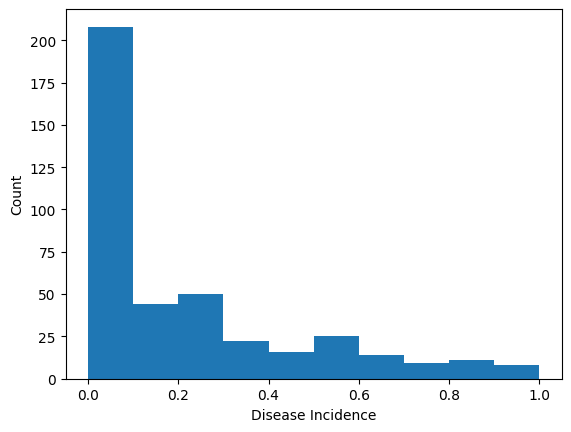

In [ ]:

# aggregated observation data
data_points = gpd.read_parquet(observation_data_path)
# meteorological data
southeastweather = xarray.open_dataset(climate_data_path)

# from hPA to kPa

southeastweather[['vpd']] = southeastweather.vpd * 0.1
southeastweather[['dpt']] = southeastweather.dpt - 273.15


data_points['year'] = data_points.reset_index()['collection'].astype(str).str[:4].astype(int)
# only data of interest
joined_2014 = data_points.loc[data_points.year == 2014]

collection_dates = joined_2014.collection.unique()
collection_dates = [datetime.strptime(str(cld), '%Y%m%d') for cld in collection_dates]

data_points['year'] = data_points.reset_index()['collection'].astype(str).str[:4].astype(int)
joined_2014 = data_points.loc[data_points.year == 2014]
print(np.sum(joined_2014.values == 0), joined_2014.shape)
plt.hist(joined_2014.disease_incidence.values)
plt.xlabel('Disease Incidence')
plt.ylabel('Count')


In [ ]:
southeastweather

<xarray.Dataset> Size: 7GB
Dimensions:        (date: 730, y: 357, x: 261)
Coordinates:
  * date           (date) datetime64[ns] 6kB 2013-01-01 ... 2014-12-31
  * y              (y) float64 3kB 23.42 23.37 23.32 23.27 ... 5.725 5.675 5.625
  * x              (x) float64 2kB 96.98 97.03 97.08 97.13 ... 109.9 109.9 110.0
Data variables: (12/13)
    precipitation  (date, y, x) float64 544MB ...
    tmin           (date, y, x) float64 544MB ...
    tmax           (date, y, x) float64 544MB ...
    dpt            (date, y, x) float64 544MB nan nan nan nan ... nan nan nan
    etr            (date, y, x) float64 544MB ...
    vpd            (date, y, x) float64 544MB nan nan nan nan ... nan nan nan
    ...             ...
    hr09           (date, y, x) float64 544MB ...
    hr12           (date, y, x) float64 544MB ...
    hr15           (date, y, x) float64 544MB ...
    hr18           (date, y, x) float64 544MB ...
    srad           (date, y, x) float64 544MB ...
    spatial_ref    int64 8B ...
Attributes:
    width:      261
    height:     357
    transform:  [ 5.00000007e-02  0.00000000e+00  9.69500041e+01  0.00000000e...
    crs:        EPSG:4326

## Meteorological data extraction for one date as an example


In [ ]:
st_date = collection_dates[0] - timedelta(days = 179)
colectiondate = southeastweather.sel(date = slice(st_date, collection_dates[0]))

range_days =  pd.Index(colectiondate.date.values) - pd.to_datetime(collection_dates[0])
partial_monthlydates = np.arange(-180, 1, 30)

ds = colectiondate.set_index(date="date")
ds = ds.rename({"date": "time"})
tmean = (ds.tmax + ds.tmin)/2
ds['tmean'] = tmean
dailyhr = ds[[f'hr{i}' for i in ['06','09','12','15','18']]].to_array(dim='hour').mean(dim='hour')
ds['dailyhr'] = dailyhr

ds['dtd'] = (ds.tmax - ds.tmin)

colectiondate.tmax.attrs['units'] = 'degC'
ds = colectiondate.set_index(date="date")
ds = ds.rename({"date": "time"})
tmean = (ds.tmax + ds.tmin)/2
ds['tmean'] = tmean
dailyhr = ds[[f'hr{i}' for i in ['06','09','12','15','18']]].to_array(dim='hour').mean(dim='hour')
ds['dailyhr'] = dailyhr


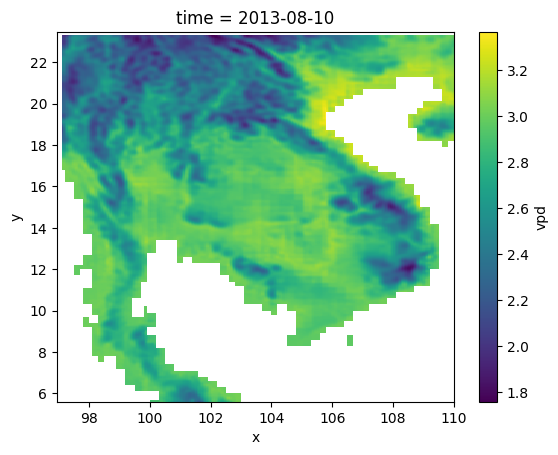

In [ ]:
ds.vpd.isel(time = 5).plot()

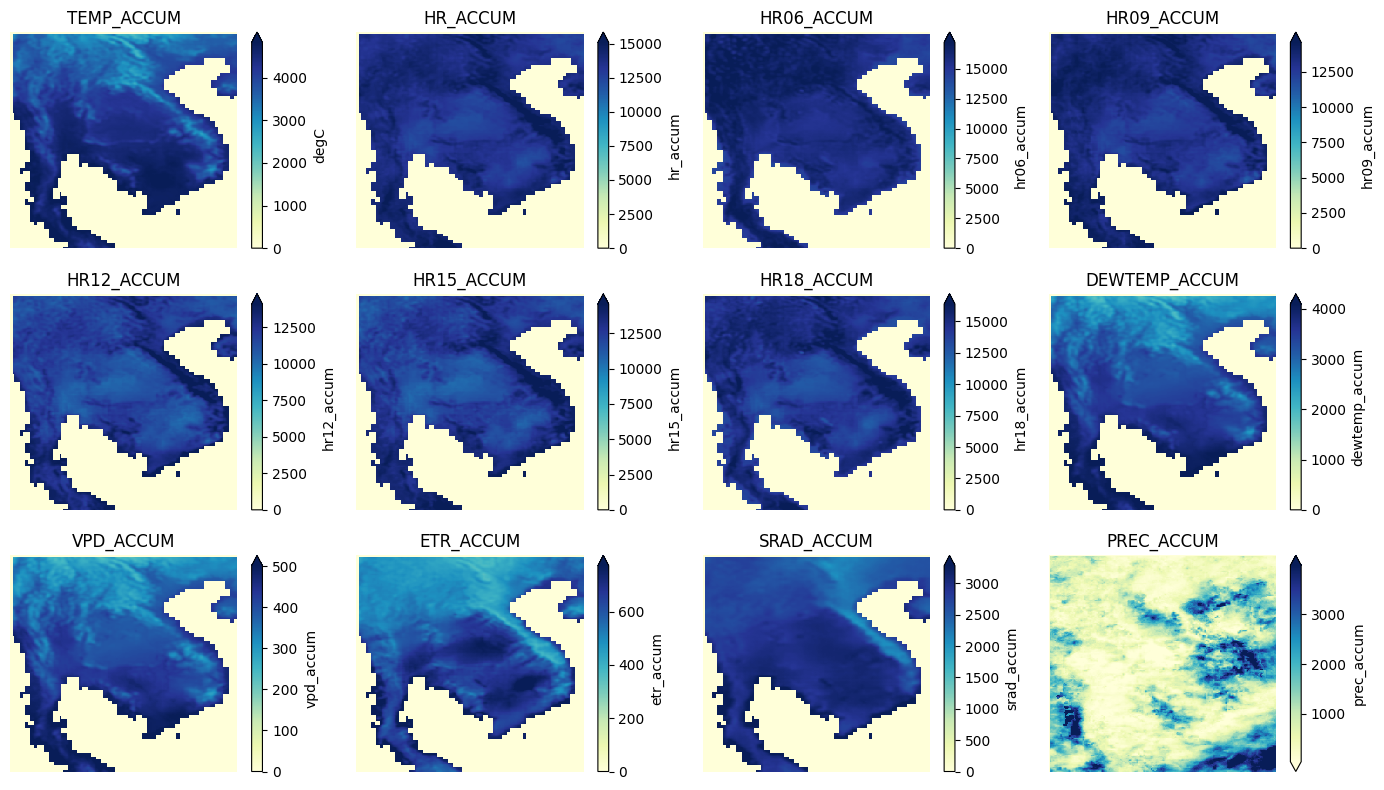

In [ ]:
### climate summary
variables_dict = {
        "temp_accum": ['tmean'],
        "hr_accum": ['dailyhr'],
        "hr06_accum": ['hr06'],
        "hr09_accum": ['hr09'],
        "hr12_accum": ['hr12'],
        "hr15_accum": ['hr15'],
        "hr18_accum": ['hr18'],
        "dewtemp_accum": ['dpt'],
        "vpd_accum": ['vpd'],
        "etr_accum": ['etr'],
        "srad_accum": ['srad'],
        "prec_accum":['precipitation'],

}
clima_summary_xarray = calculate_meteorological_summaries(ds , variables_dict)


plot_facet_grid(clima_summary_xarray, ncols=4, figsize = (14,8))

In [ ]:

def plot_facet_grid_with_points(xr_ds, points_gdf=None, ncols=3, figsize=(15, 12)):
    # Obtener las variables del dataset
    variables = list(xr_ds.data_vars)
    n_vars = len(variables)
    nrows = math.ceil(n_vars / ncols)

    # Crear la figura matriz
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, var_name in enumerate(variables):
        ax = axes[i]

        # 1. DIBUJAR EL RASTER (Índice Climático)
        xr_ds[var_name].plot(
            ax=ax,
            robust=True,
            cmap="YlGnBu",
            cbar_kwargs={'label': getattr(xr_ds[var_name], 'units', '')}
        )

        # 2. SUPERPONER LOS PUNTOS (GeoPandas)
        if points_gdf is not None:
            # Dibujamos los puntos en el mismo eje (ax=ax)
            points_gdf.plot(
                ax=ax,
                color='red',           # Color de los puntos
                markersize=15,         # Tamaño del punto
                edgecolor='black',     # Borde negro para que resalten
                linewidth=0.5,
                alpha=0.8              # Un poco transparentes
            )

        ax.set_title(var_name.upper())
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    # Ocultar los subplots sobrantes si los hay
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

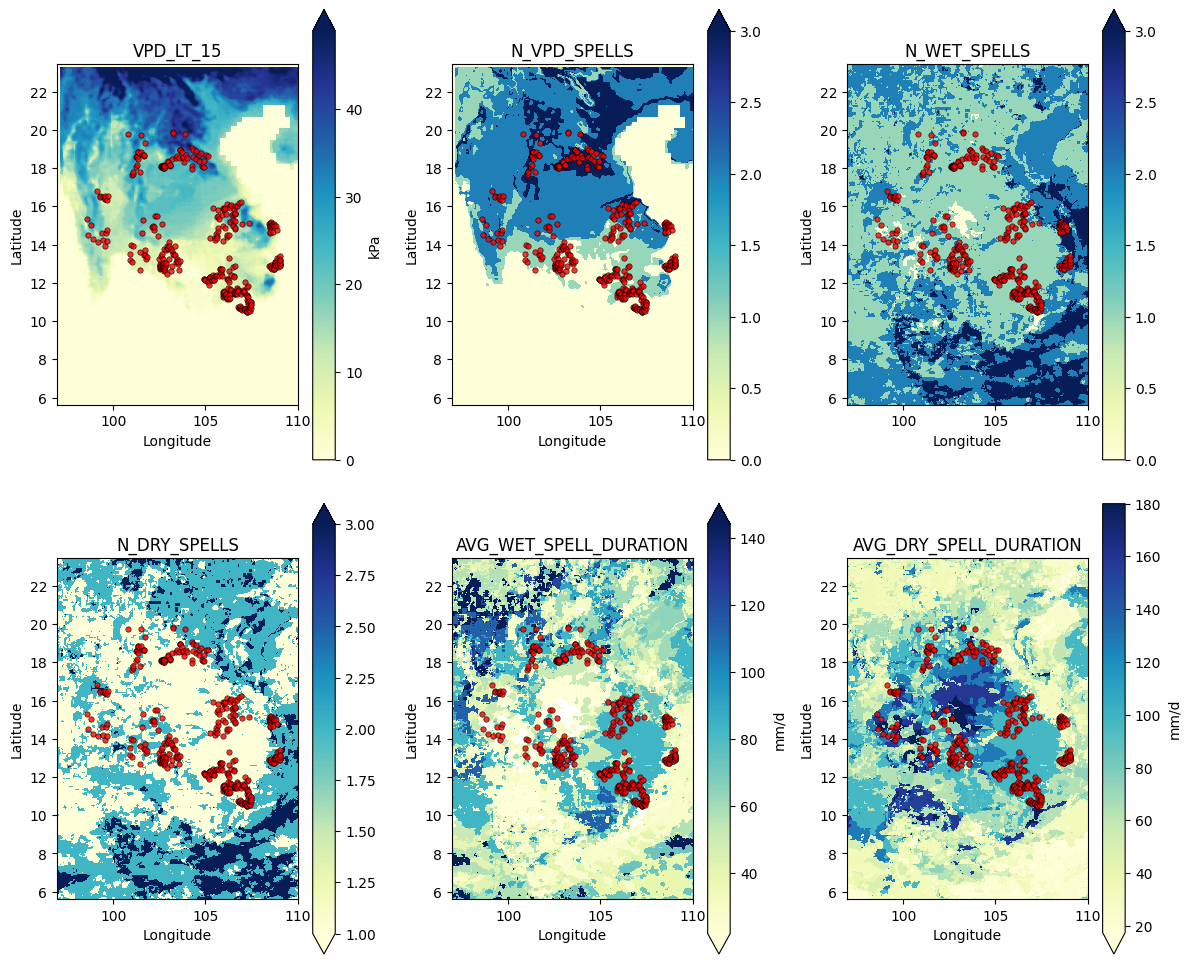

In [ ]:

indices_dict = {
        "vpd_lt_15": ['vpd', 1.5],
        "n_vpd_spells": ['vpd', 1.5, 7],
        "n_wet_spells": ['precipitation', 1.0, 5],
        "n_dry_spells": ['precipitation', 1.0, 5],
        "avg_wet_spell_duration": ['precipitation', 1.0, 5],
        "avg_dry_spell_duration": ['precipitation', 1.0, 5],

}

cl_ind_xarray = calculate_indices(ds , indices_dict)
plot_facet_grid_with_points(cl_ind_xarray,
                    points_gdf = joined_2014,
                ncols=3, figsize=(12,10))

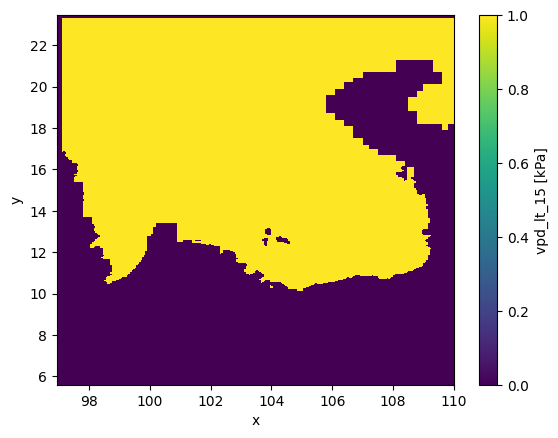

In [ ]:
xarray.where(cl_ind_xarray.vpd_lt_15, cl_ind_xarray.vpd_lt_15>0.5, 0).plot()

In [ ]:
## extracting data using coordinates

climatedata_subset = xarray.merge([clima_summary_xarray, cl_ind_xarray])


joined_2014.collection = joined_2014.collection.map(lambda x: str(x))
datasubset = joined_2014.loc[joined_2014.collection == collection_dates[0].strftime('%Y%m%d')]

extracting_using_gpdf(datasubset, climatedata_subset)



NameError: name 'clima_summary_xarray' is not defined

In [ ]:
from tqdm import tqdm
### This step takse 20 minutes aprox
variables_dict = {
        "temp_accum": ['tmean'],
        "hr_accum": ['dailyhr'],
        "hr06_accum": ['hr06'],
        "hr09_accum": ['hr09'],
        "hr12_accum": ['hr12'],
        "hr15_accum": ['hr15'],
        "hr18_accum": ['hr18'],
        "dewtemp_accum": ['dpt'],
        "vpd_accum": ['vpd'],
        "etr_accum": ['etr'],
        "srad_accum": ['srad'],
        "prec_accum":['precipitation'],

}

indices_dict = {
        "vpd_lt_15": ['vpd', 1.5],
        "n_vpd_spells": ['vpd', 1.5, 7],
        "n_wet_spells": ['precipitation', 1.0, 7],
        "n_dry_spells": ['precipitation', 1.0, 7],
        "avg_wet_spell_duration": ['precipitation', 1.0, 7],
        "avg_dry_spell_duration": ['precipitation', 1.0, 7],
        "rh_85_90_days": [['dailyhr', 'hr06','hr09','hr12', 'hr15','hr18'], [85, 90], ['>=', '<=']],
        "tmean_25_30_days": ['tmean', [25, 30], ['>=', '<=']],
        "max_temp_days": ['tmax', 32],
        "precip_max_15d": ['precipitation'],
        "max_hr_days": ['dailyhr', 80],
        "consecutive_dry_days": ['precipitation', 1.0],
        "growing_degree_days": ['tmean', 15],
        "daily_intensity_index": ['precipitation', 1.0],
        "disease_pressure_index": ['vpd']
}


df_list = []
for i in tqdm(range(len(collection_dates))):
        date_oi = collection_dates[i]
        print(f'Extracting data for {date_oi}')
        st_date = date_oi - timedelta(days = 179)

        colectiondate = southeastweather.sel(date = slice(st_date, date_oi))
        range_days =  pd.Index(colectiondate.date.values) - pd.to_datetime(date_oi)
        partial_monthlydates = np.arange(-180, 1, 30)

        ds = colectiondate.set_index(date="date")
        ds = ds.rename({"date": "time"})
        tmean = (ds.tmax + ds.tmin)/2
        ds['tmean'] = tmean
        dailyhr = ds[[f'hr{i}' for i in ['06','09','12','15','18']]].to_array(dim='hour').mean(dim='hour')
        ds['dailyhr'] = dailyhr

        clima_summary_xarray = calculate_meteorological_summaries(ds , variables_dict)
        cl_ind_xarray = calculate_indices(ds , indices_dict)
        climatedata_subset = xarray.merge([clima_summary_xarray, cl_ind_xarray])

        joined_2014.collection = joined_2014.collection.map(lambda x: str(x))
        datasubset = joined_2014.loc[joined_2014.collection == date_oi.strftime('%Y%m%d')]

        df_list.append(extracting_using_gpdf(datasubset, climatedata_subset))


  0%|          | 0/60 [00:00<?, ?it/s]

Extracting data for 2014-02-05 00:00:00


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
  2%|▏         | 1/60 [00:42<41:24, 42.11s/it]

Extracting data for 2014-03-25 00:00:00


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
  3%|▎         | 2/60 [01:16<36:11, 37.44s/it]

...

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
 97%|█████████▋| 58/60 [32:58<01:07, 33.56s/it]

Extracting data for 2014-03-10 00:00:00


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
 98%|█████████▊| 59/60 [33:31<00:33, 33.54s/it]

Extracting data for 2014-03-09 00:00:00


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
100%|██████████| 60/60 [34:05<00:00, 34.09s/it]


In [ ]:
### Export data

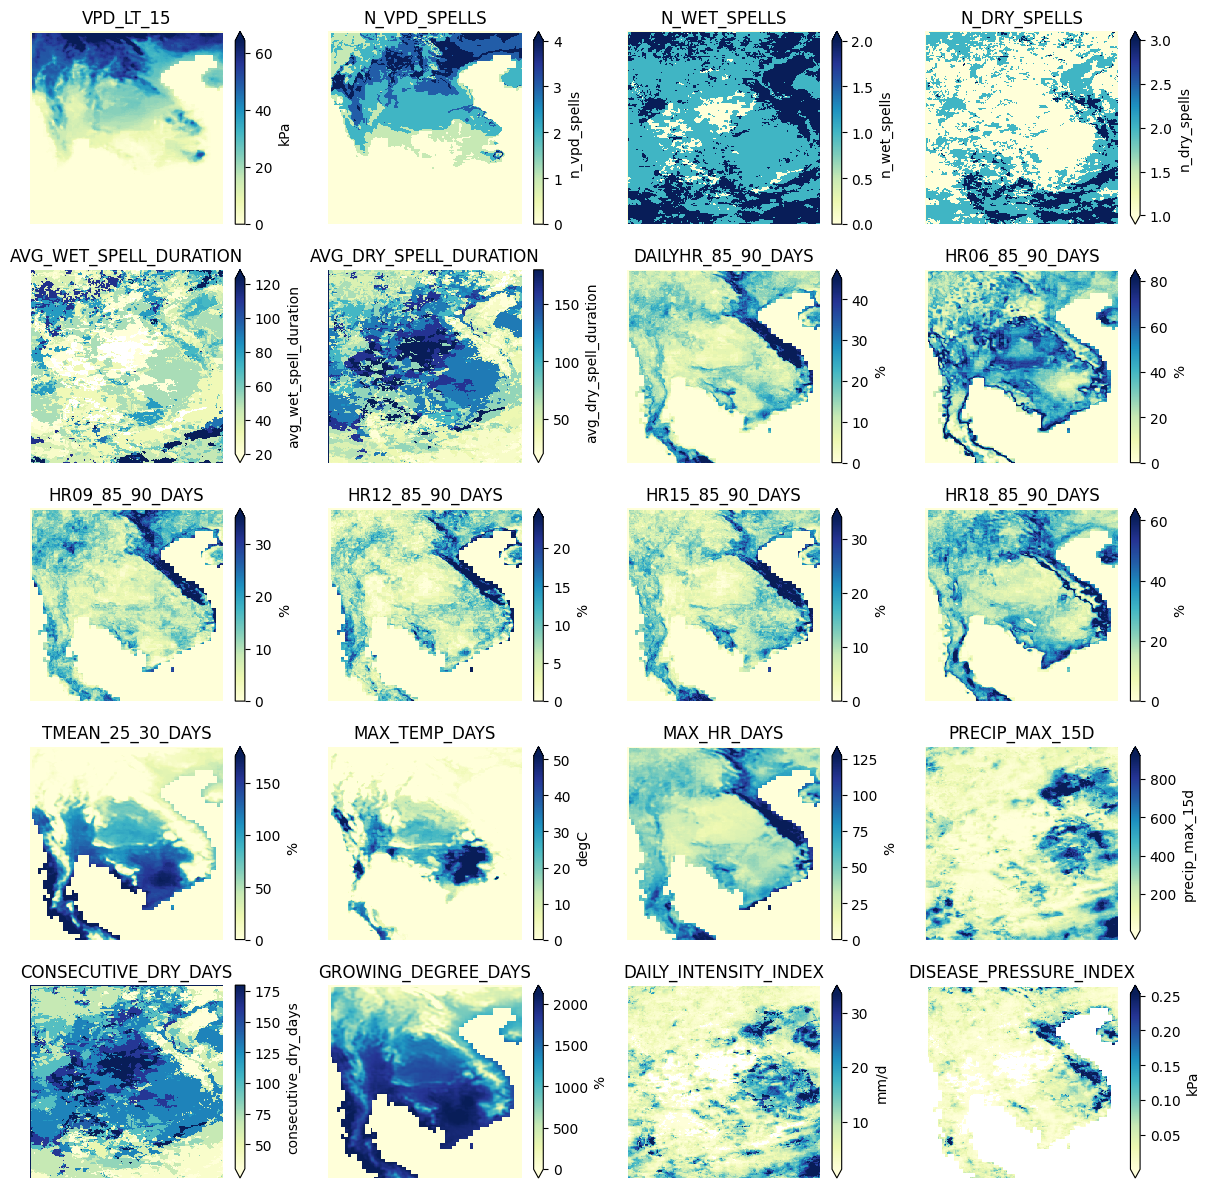

In [ ]:
plot_facet_grid(cl_ind_xarray, ncols=4, figsize=(12,12))

In [ ]:

gpd_data = gpd.GeoDataFrame(
        pd.concat(df_list),
        geometry=pd.concat(df_list).geometry,
        crs='EPSG:4326'
    )
gpd_data.to_parquet('climate_incidence.parquet')


In [ ]:
gpd_data

,index,collection,disease_incidence,latitude,longitude,unique_id,cell_id,geometry,year,y,...,hr15_85_90_days,hr18_85_90_days,tmean_25_30_days,max_temp_days,max_hr_days,precip_max_15d,consecutive_dry_days,growing_degree_days,daily_intensity_index,disease_pressure_index
0,0,20140205,0.06,19.770067,19.770067,100.838756_19.770067_20140205_19130,19130,POINT (100.825 19.775),2014,19.774999,...,25.0,38.0,3.0,0,93,273.425789,97.0,989.027538,7.236760,0.062377
1,0,20140205,0.00,17.626283,17.626283,101.023523_17.626283_20140205_30357,30357,POINT (101.025 17.625),2014,17.624999,...,12.0,50.0,0.0,0,67,198.774962,67.0,869.716788,5.425687,0.040690
2,0,20140205,0.58,17.745106,17.745106,101.090502_17.745106_20140205_29836,29836,POINT (101.075 17.725),2014,17.724999,...,13.0,44.0,0.0,0,66,51.382102,97.0,886.210081,2.549207,0.013852
3,0,20140205,0.00,17.813284,17.813284,101.446179_17.813284_20140205_29321,29321,POINT (101.425 17.825),2014,17.824999,...,7.0,17.0,59.0,2,42,94.988916,128.0,1412.674043,3.431131,0.009414
4,0,20140205,0.06,19.713547,19.713547,101.547801_19.713547_20140205_19405,19405,POINT (101.525 19.725),2014,19.724999,...,16.0,34.0,0.0,0,75,628.754196,67.0,889.185336,10.811524,0.093783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,0,20140309,0.00,16.477924,16.477924,99.430184_16.477924_20140309_36328,36328,POINT (99.425 16.475),2014,16.474999,...,5.0,19.0,95.0,20,34,268.307390,99.0,1732.195987,11.480177,0.025834
2,0,20140309,0.00,16.429371,16.429371,99.527355_16.429371_20140309_36591,36591,POINT (99.525 16.425),2014,16.424999,...,2.0,19.0,103.0,20,30,240.663471,99.0,1775.358502,16.044231,0.031135
3,0,20140309,0.12,16.367486,16.367486,99.541236_16.367486_20140309_36852,36852,POINT (99.525 16.375),2014,16.374999,...,3.0,22.0,98.0,20,32,208.062615,99.0,1762.904389,13.870841,0.028386
4,0,20140309,0.02,16.364100,16.364100,99.569256_16.3641_20140309_36853,36853,POINT (99.575 16.375),2014,16.374999,...,2.0,22.0,104.0,20,30,213.852868,99.0,1784.721373,14.256858,0.027216


## Explanatory variables

In [ ]:
wb_weatherdata = gpd.read_parquet(disease_incidence_with_data)

In [ ]:
wb_weatherdata.columns

Index(['index', 'collection', 'disease_incidence', 'latitude', 'longitude',
       'unique_id', 'cell_id', 'geometry', 'year', 'y', 'x', 'temp_accum',
       'hr_accum', 'hr06_accum', 'hr09_accum', 'hr12_accum', 'hr15_accum',
       'hr18_accum', 'dewtemp_accum', 'vpd_accum', 'etr_accum', 'srad_accum',
       'prec_accum', 'vpd_lt_15', 'n_vpd_spells', 'n_wet_spells',
       'n_dry_spells', 'avg_wet_spell_duration', 'avg_dry_spell_duration',
       'dailyhr_85_90_days', 'hr06_85_90_days', 'hr09_85_90_days',
       'hr12_85_90_days', 'hr15_85_90_days', 'hr18_85_90_days',
       'tmean_25_30_days', 'max_temp_days', 'max_hr_days', 'precip_max_15d',
       'consecutive_dry_days', 'growing_degree_days', 'daily_intensity_index',
       'disease_pressure_index'],
      dtype='object')

In [ ]:
wb_weatherdata[['temp_avg', 'hr_avg', 'hr06_avg', 'hr09_avg', 'hr12_avg',
       'hr15_avg', 'hr18_avg', 'dewtemp_avg', 'vpd_avg', 'etr_avg', 'srad_avg',
       'prec_accum', 'dtd_m1', 'dtd_m2', 'dtd_m3', 'dtd_m4', 'dtd_m5',
       'dtd_m6', 'max_temp_days', 'max_hr_days', 'precip_max_15d',
       'consecutive_dry_days', 'growing_degree_days', 'daily_intensity_index',
       'disease_pressure_index', 'visual_symptom_frequency']]

Proportion of ZEROS in Train: 33.99%
Proportion of ZEROS in Test:  39.39%
Model R-squared (Train): 0.51
Model R-squared (Test): 0.42


/tmp/ipykernel_2897/111807834.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=rf_importance, palette='viridis')


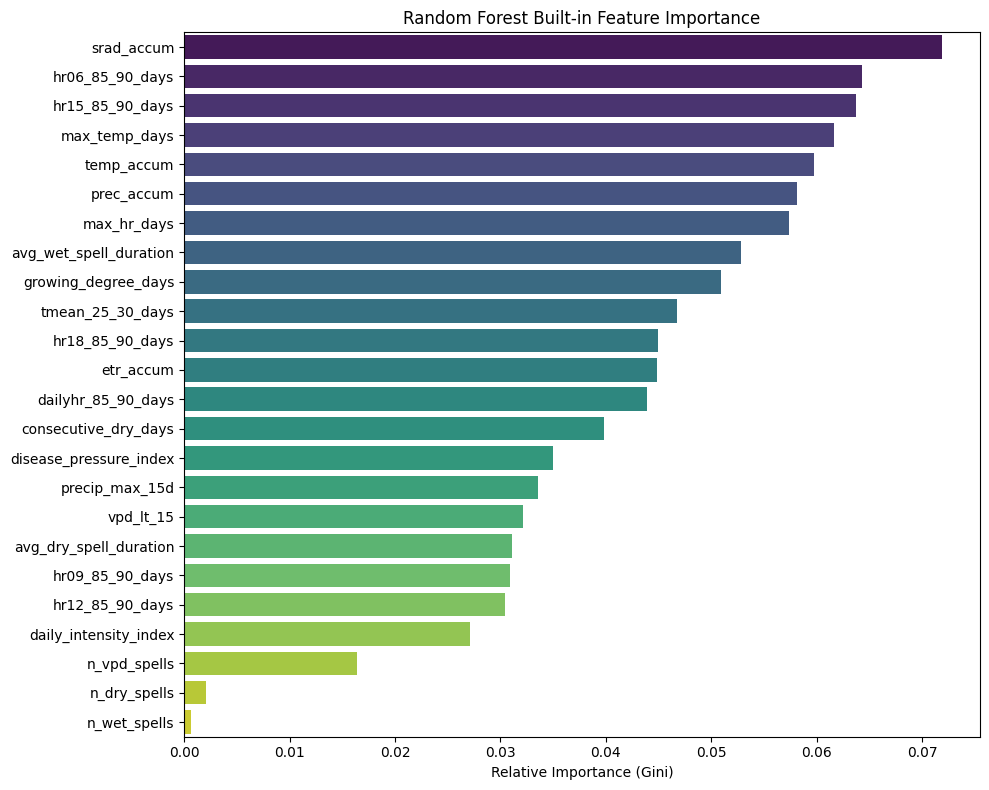

Calculating Permutation Importance (this may take a moment)...


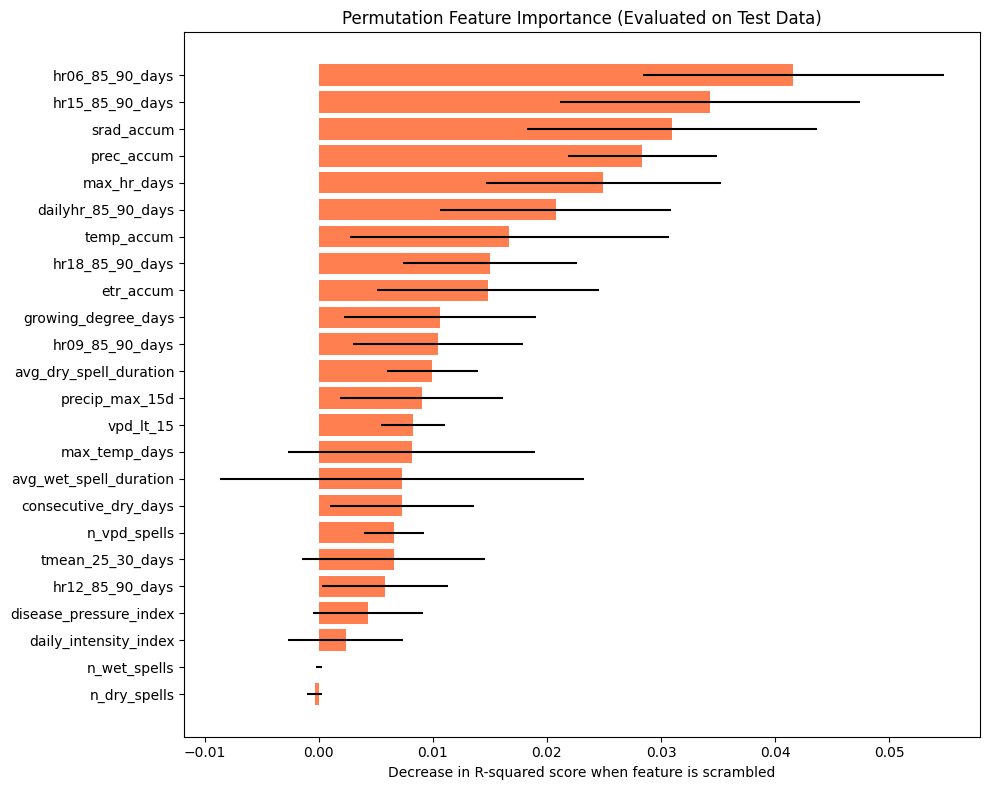

In [ ]:

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

features = [
    'temp_accum',
    'hr_accum', 'hr06_accum', 'hr09_accum', 'hr12_accum', 'hr15_accum',
    'hr18_accum', 'dewtemp_accum', 'vpd_accum', 'etr_accum', 'srad_accum',
    'prec_accum', 'vpd_lt_15', 'n_vpd_spells', 'n_wet_spells',
    'n_dry_spells', 'avg_wet_spell_duration', 'avg_dry_spell_duration',
    'dailyhr_85_90_days', 'hr06_85_90_days', 'hr09_85_90_days',
    'hr12_85_90_days', 'hr15_85_90_days', 'hr18_85_90_days',
    'tmean_25_30_days', 'max_temp_days', 'max_hr_days', 'precip_max_15d',
    'consecutive_dry_days', 'growing_degree_days', 'daily_intensity_index',
    'disease_pressure_index'
]

features = [
    'temp_accum',
    'etr_accum', 'srad_accum',
    'prec_accum', 'vpd_lt_15', 'n_vpd_spells', 'n_wet_spells',
    'n_dry_spells', 'avg_wet_spell_duration', 'avg_dry_spell_duration',
    'dailyhr_85_90_days', 'hr06_85_90_days', 'hr09_85_90_days',
    'hr12_85_90_days', 'hr15_85_90_days', 'hr18_85_90_days',
    'tmean_25_30_days', 'max_temp_days', 'max_hr_days', 'precip_max_15d',
    'consecutive_dry_days', 'growing_degree_days', 'daily_intensity_index',
    'disease_pressure_index'
]


model_data = wb_weatherdata[['cell_id'] + features + ['disease_incidence']].dropna()

X = model_data[features]
y = model_data['disease_incidence']
groups = model_data['cell_id']

y_stratify_label = (y > 0).astype(int)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in sgkf.split(X, y_stratify_label, groups):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    break
# --- Quick Check to prove it worked ---
print("Proportion of ZEROS in Train: {:.2f}%".format((y_train == 0).mean() * 100))
print("Proportion of ZEROS in Test:  {:.2f}%".format((y_test == 0).mean() * 100))

#  TRAIN THE RANDOM FOREST MODEL

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print(f"Model R-squared (Train): {train_score:.2f}")
print(f"Model R-squared (Test): {test_score:.2f}")

# -------------------------------------------------------------------
# METHOD 1: STANDARD FEATURE IMPORTANCE (MDI)
# -------------------------------------------------------------------
rf_importance = pd.DataFrame({
    'Variable': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Variable', data=rf_importance, palette='viridis')
plt.title('Random Forest Built-in Feature Importance')
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('')
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# METHOD 2: PERMUTATION IMPORTANCE (More reliable for correlated data)
# -------------------------------------------------------------------
# Permutation importance shuffles each variable one by one and measures
# how much the model's error increases. High increase = highly important variable.
print("Calculating Permutation Importance (this may take a moment)...")
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Create a DataFrame for permutation results
perm_df = pd.DataFrame({
    'Variable': features,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

plt.figure(figsize=(10, 8))
# Plotting the mean importance with error bars
plt.barh(perm_df['Variable'][::-1], perm_df['Importance_Mean'][::-1],
         xerr=perm_df['Importance_Std'][::-1], align='center', color='coral')
plt.title('Permutation Feature Importance (Evaluated on Test Data)')
plt.xlabel('Decrease in R-squared score when feature is scrambled')
plt.tight_layout()
plt.show()

In [ ]:
X_train.shape

(306, 24)

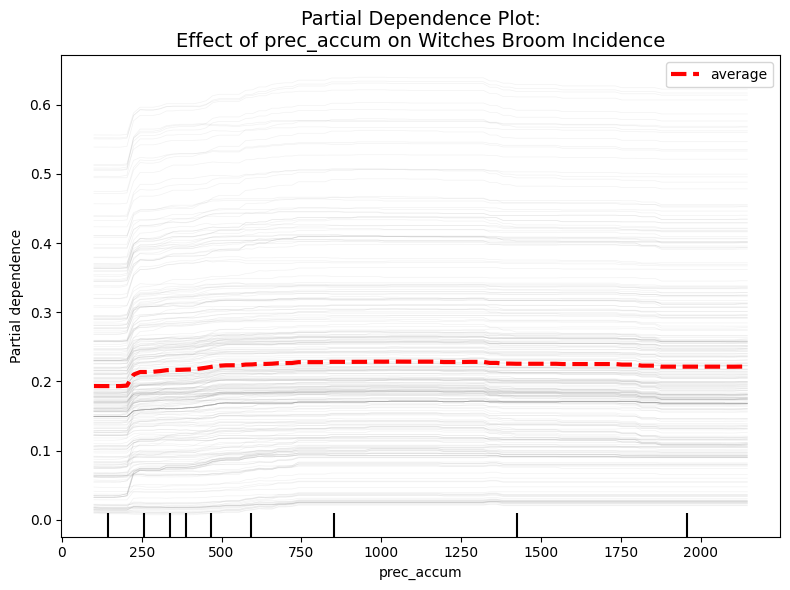

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(figsize=(8, 6))

# Generate the Partial Dependence Plot (PDP)
# We use X_train here because we want to see what the model learned
# from the data distribution it was trained on.
display = PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=X_train,
    features=['prec_accum'], # The variable you want to analyze
    kind='both',                  # 'both' plots the average line AND individual lines (ICE)
    ax=ax,
    line_kw={"color": "red", "linewidth": 3}, # Style for the main average line
    ice_lines_kw={"color": "gray", "alpha": 0.1, "linewidth": 0.5} # Style for individual data points
)

# Formatting the plot to make it look professional
ax.set_title("Partial Dependence Plot:\nEffect of prec_accum on Witches Broom Incidence", fontsize=14)
ax.set_ylabel("Predicted Disease Incidence", fontsize=12)
#ax.set_xlabel("Number of days where HR at 15:00 is between 85-90%", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
X_test.shape

(66, 32)